In [1]:
%load_ext autoreload
%autoreload 2

import os

import numpy as np
import unyt as u

import dev
import richio


In [2]:
DATADIR = "/home/hey4/rich_tde/data/processed/SimpleTimeseries"

configs = {
    "1e4": {
        "Rstar": 0.47 * richio.units.lscale,
        "Mstar": 0.5 * richio.units.mscale,
        "Mbh": 1e4 * richio.units.mscale,
    },
    "1e5": {
        "Rstar": 0.47 * richio.units.lscale,
        "Mstar": 0.5 * richio.units.mscale,
        "Mbh": 1e5 * richio.units.mscale,
    },
    "1e6": {
        "Rstar": 1 * richio.units.lscale,
        "Mstar": 1 * richio.units.mscale,
        "Mbh": 1e6 * richio.units.mscale,
    },
}

for mode, cfg in configs.items():
    Rstar, Mstar, Mbh = cfg["Rstar"], cfg["Mstar"], cfg["Mbh"]
    r_p = Rstar * (Mbh / Mstar) ** (1 / 3)
    cfg["tmin"] = (
        np.pi
        / np.sqrt(2)
        * (Rstar**3 / u.G / Mstar) ** (1 / 2)
        * (Mbh / Mstar) ** (1 / 2)
    )
    cfg["Delta"] = u.G * Mbh / (4 * r_p) * Mstar / 2
    cfg["DATAFILE"] = os.path.join(DATADIR, f"Ediss-t-{mode}-final.txt")
    print((cfg["Delta"]/cfg["tmin"]/20).in_cgs())

4.07081009057643e+43 erg/s
5.975132069576614e+43 erg/s
6.693636801821886e+43 erg/s


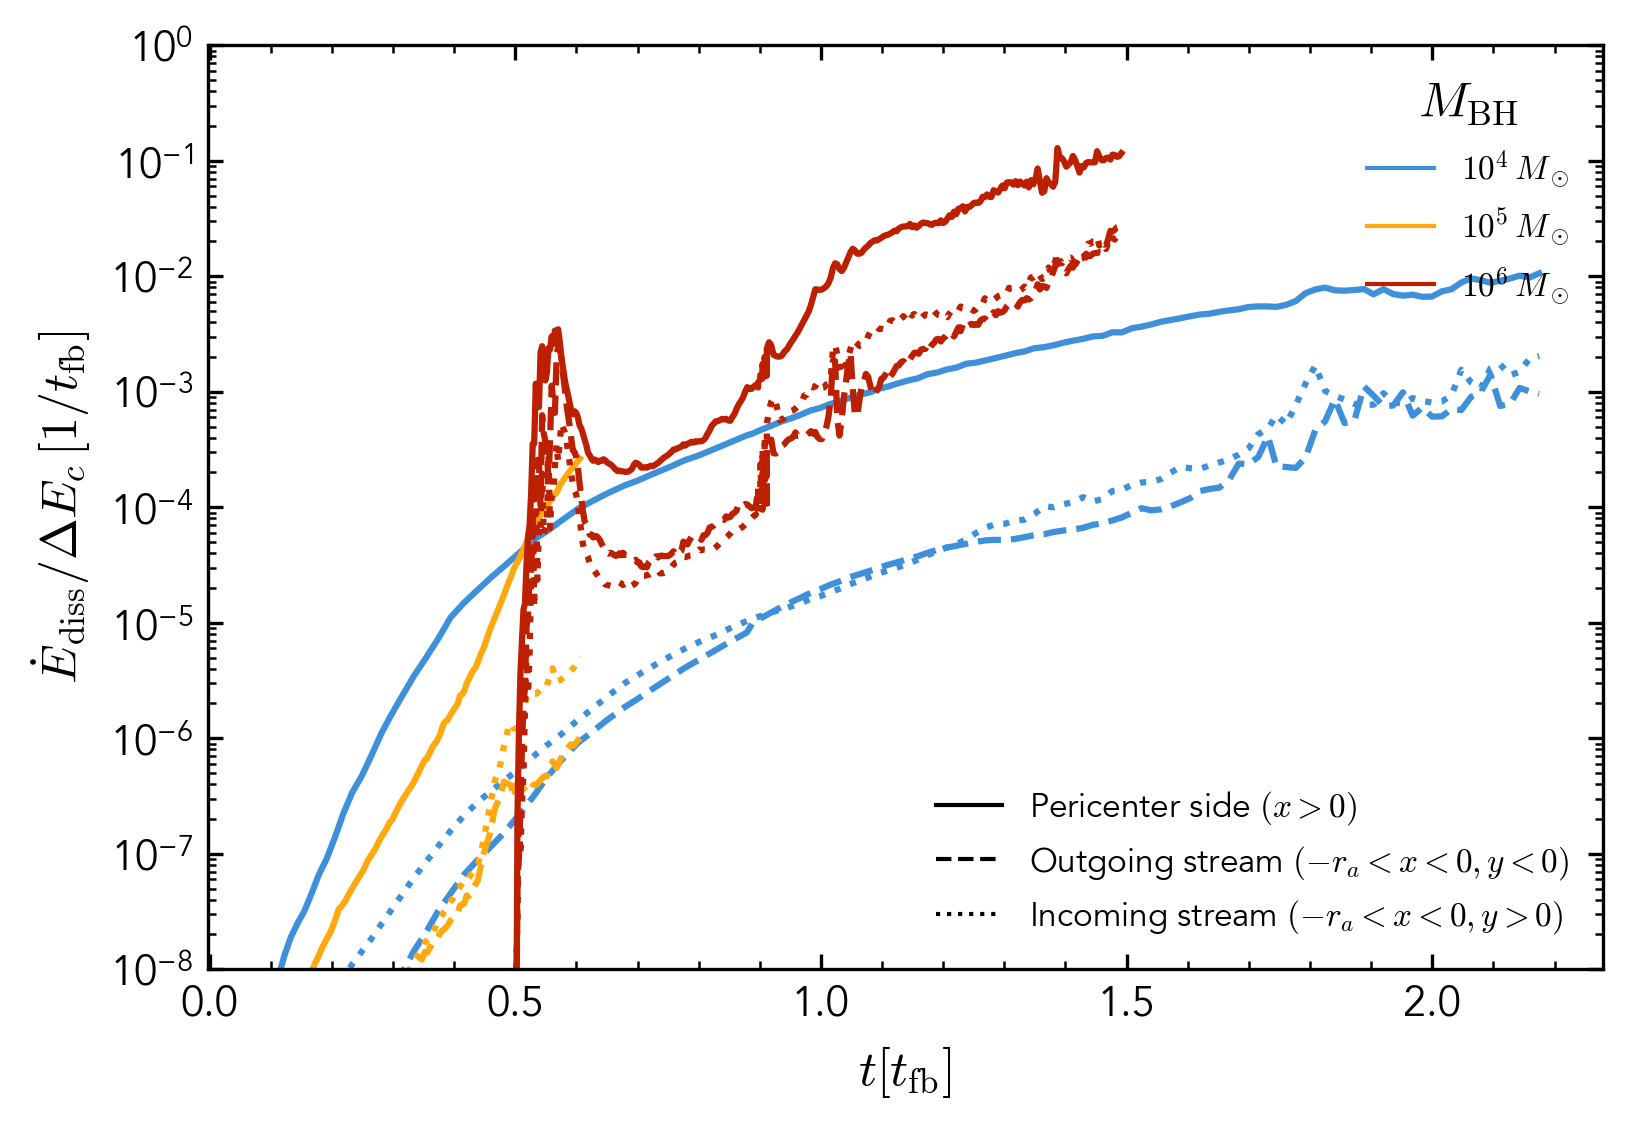

In [3]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

reg = richio.units.registry
regions = [
    "Pericenter side $(x>0)$",
    "Outgoing stream $(-r_a<x<0, y<0)$",
    "Incoming stream $(-r_a<x<0, y>0)$",
    # "The rest $(x<-r_a)$",
]

region_styles = ["-", "--", ":", "-."]
mode_colors = {"1e4": "C0", "1e5": "C1", "1e6": "C2"}
mode_labels = {"1e4": r"$10^4\,M_\odot$", "1e5": r"$10^5\,M_\odot$", "1e6": r"$10^6\,M_\odot$"}

plt.figure(figsize=(6, 4), dpi=300)
for mode, cfg in configs.items():
    raw = np.loadtxt(cfg["DATAFILE"], delimiter="\t").T
    raw = raw[:, np.argsort(raw[1])]
    raw = raw[:, raw[2] >= 0.1]
    t_in_tmins = raw[2]
    Ediss = u.unyt_array(
        raw[3:6], "code_length**2*code_mass/code_time**3", registry=reg
    )
    Ediss_Deltas = Ediss / cfg["Delta"] * cfg["tmin"]

    for row, style in zip(Ediss_Deltas, region_styles):
        plt.plot(t_in_tmins, row, color=mode_colors[mode], linestyle=style, linewidth=1.5)

plt.xlabel(r"$t[t_\mathrm{fb}]$")
plt.ylabel(r"$\dot{E}_\mathrm{diss}/\Delta E_c\,[1/t_\mathrm{fb}]$")
plt.yscale("log")
plt.ylim(1e-8, 1)

region_handles = [Line2D([], [], color="k", linestyle=s, label=r) for s, r in zip(region_styles, regions)]
mode_handles = [Line2D([], [], color=mode_colors[m], label=mode_labels[m]) for m in configs]
region_legend = plt.legend(handles=region_handles, loc="lower right", fontsize=8)
plt.gca().add_artist(region_legend)
plt.legend(handles=mode_handles, title=r"$M_\mathrm{BH}$", loc="upper right", fontsize=8)

# plt.gca().tick_params(which="both", top=False)
# plt.grid()
plt.show()


/home/hey4/.conda/envs/richanalysis/lib/python3.13/site-packages/unyt/array.py:1972: RuntimeWarning: invalid value encountered in divide
  out_arr = func(


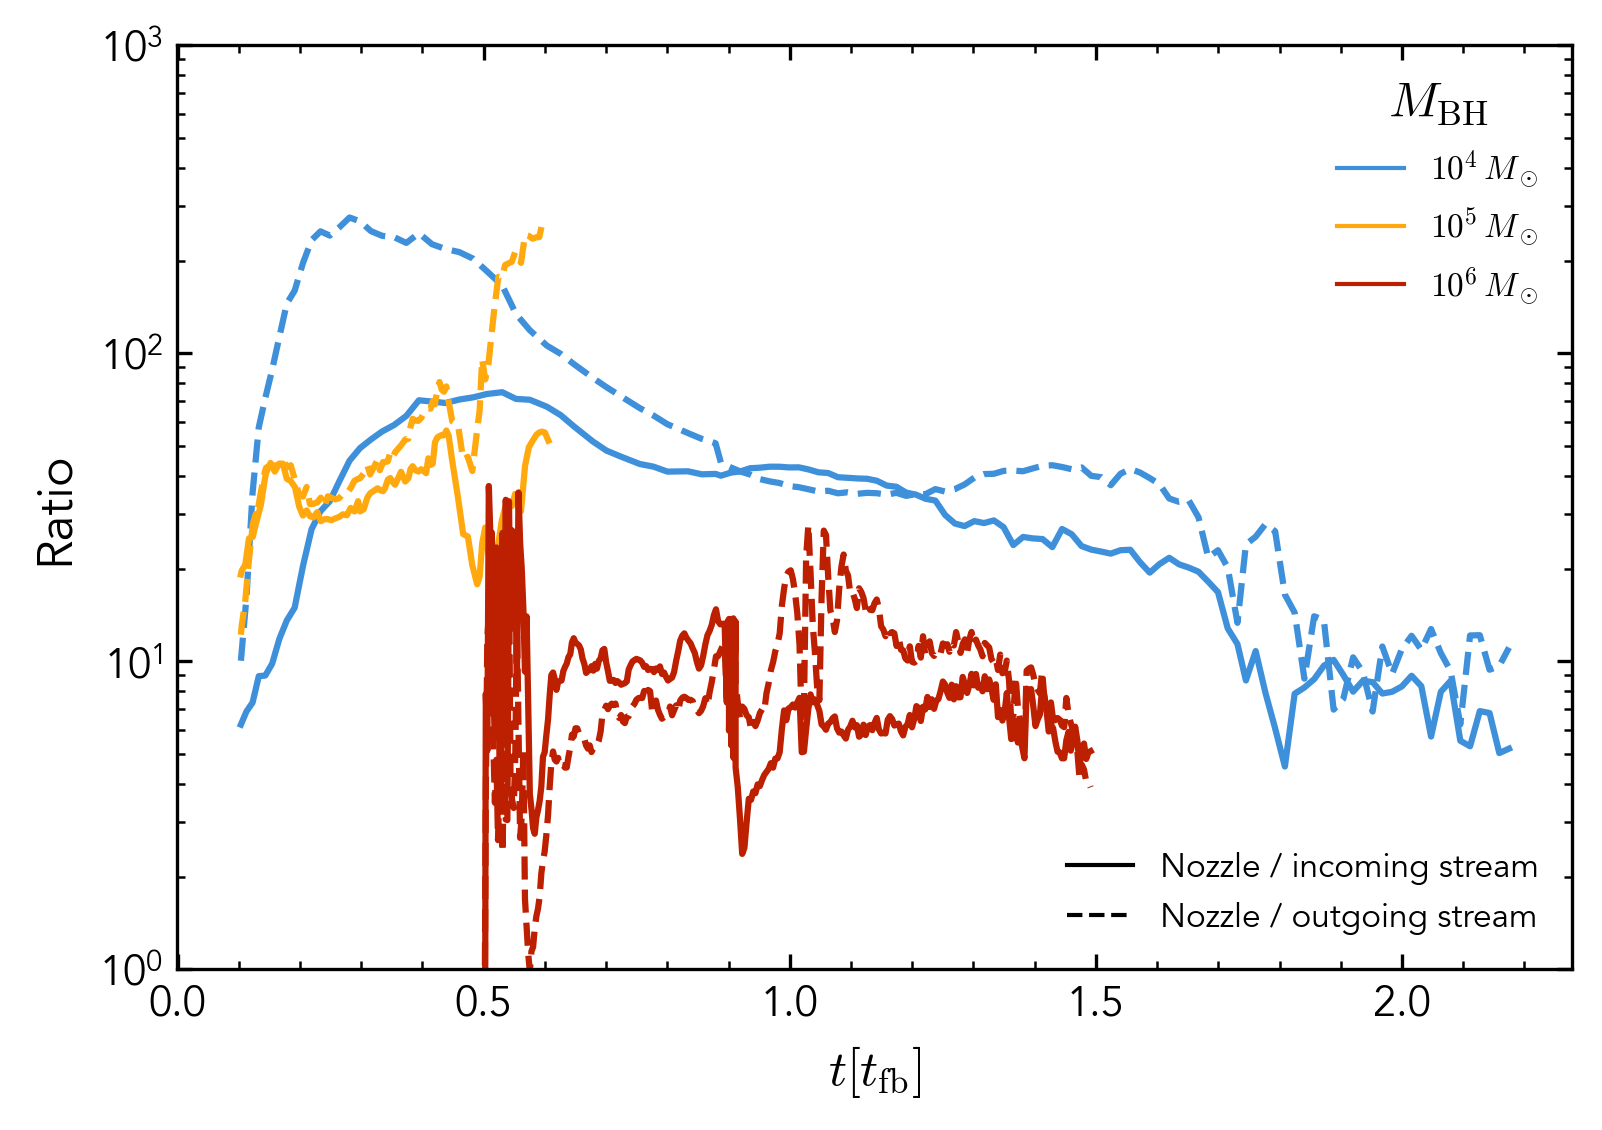

In [4]:
ratio_styles = ["-", "--"]
ratio_labels = ["Nozzle / incoming stream", "Nozzle / outgoing stream"]

plt.figure(figsize=(6, 4), dpi=300)
for mode, cfg in configs.items():
    raw = np.loadtxt(cfg["DATAFILE"], delimiter="\t").T
    raw = raw[:, np.argsort(raw[1])]
    raw = raw[:, raw[2] >= 0.1]
    t_in_tmins = raw[2]
    Ediss = u.unyt_array(raw[3:7], "code_length**2*code_mass/code_time**3", registry=reg)
    Ediss1, Ediss2, Ediss3, Ediss4 = Ediss

    plt.plot(t_in_tmins, Ediss1 / Ediss3, color=mode_colors[mode], linestyle=ratio_styles[0], linewidth=1.5)
    plt.plot(t_in_tmins, Ediss1 / Ediss2, color=mode_colors[mode], linestyle=ratio_styles[1], linewidth=1.5)

plt.xlabel(r"$t[t_\mathrm{fb}]$")
plt.ylabel("Ratio")
plt.yscale("log")
plt.ylim(1e0, 1e3)

ratio_handles = [Line2D([], [], color="k", linestyle=s, label=l) for s, l in zip(ratio_styles, ratio_labels)]
mode_handles = [Line2D([], [], color=mode_colors[m], label=mode_labels[m]) for m in configs]
ratio_legend = plt.legend(handles=ratio_handles, loc="lower right", fontsize=8)
plt.gca().add_artist(ratio_legend)
plt.legend(handles=mode_handles, title=r"$M_\mathrm{BH}$", loc="upper right", fontsize=8)
plt.show()


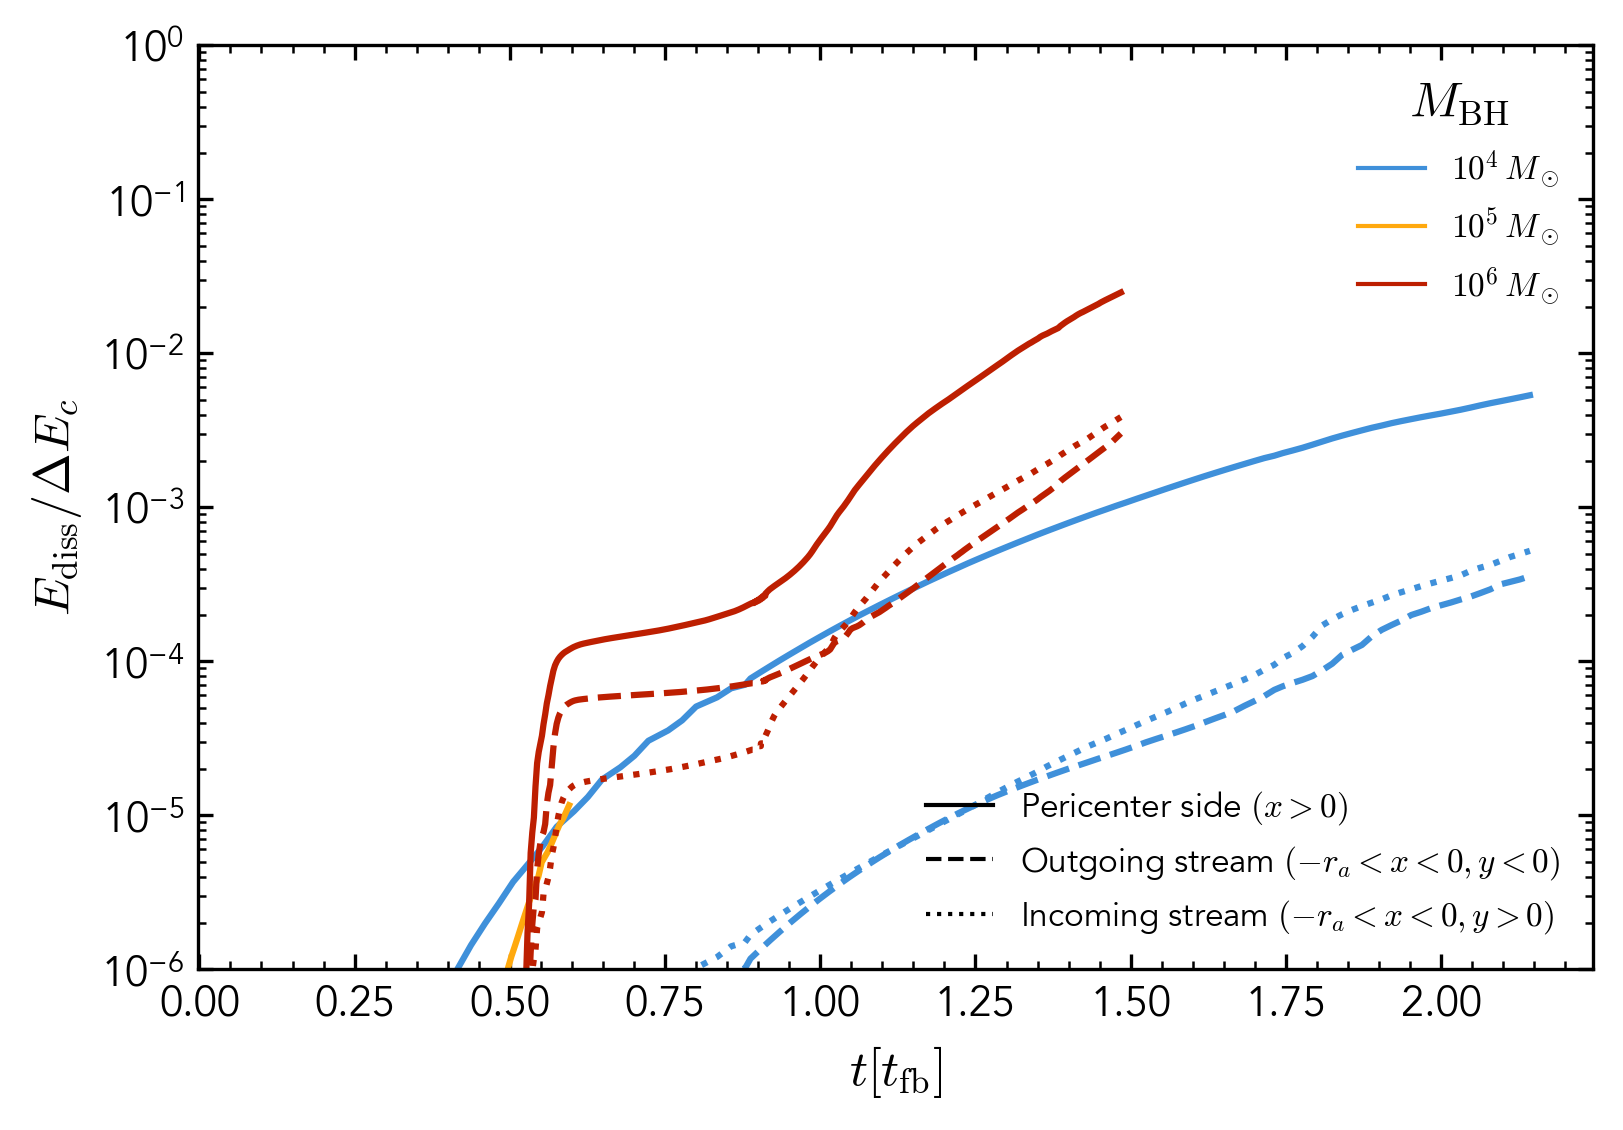

In [5]:
plt.figure(figsize=(6, 4), dpi=300)
for mode, cfg in configs.items():
    raw = np.loadtxt(cfg["DATAFILE"], delimiter="\t").T
    raw = raw[:, np.argsort(raw[1])]
    raw = raw[:, raw[2] >= 0.1]
    ts = raw[1]
    t_in_tmins = raw[2]
    Ediss = u.unyt_array(raw[3:7], "code_length**2*code_mass/code_time**3", registry=reg)
    Ediss_Deltas = Ediss / cfg["Delta"]

    for row, style in zip(Ediss_Deltas[:3], region_styles):
        integrated = [np.sum(row[: i - 1] * (ts[1:i] - ts[: i - 1])) for i in range(2, len(ts))]
        plt.plot(t_in_tmins[:-2], integrated, color=mode_colors[mode], linestyle=style, linewidth=1.5)

plt.xlabel(r"$t[t_\mathrm{fb}]$")
plt.ylabel(r"${E}_\mathrm{diss}/\Delta E_c$")
plt.yscale("log")
plt.ylim(1e-6, 1)

region_handles = [Line2D([], [], color="k", linestyle=s, label=r) for s, r in zip(region_styles, regions)]
mode_handles = [Line2D([], [], color=mode_colors[m], label=mode_labels[m]) for m in configs]
region_legend = plt.legend(handles=region_handles, loc="lower right", fontsize=8)
plt.gca().add_artist(region_legend)
plt.legend(handles=mode_handles, title=r"$M_\mathrm{BH}$", loc="upper right", fontsize=8)
plt.show()


Energy budget vs t

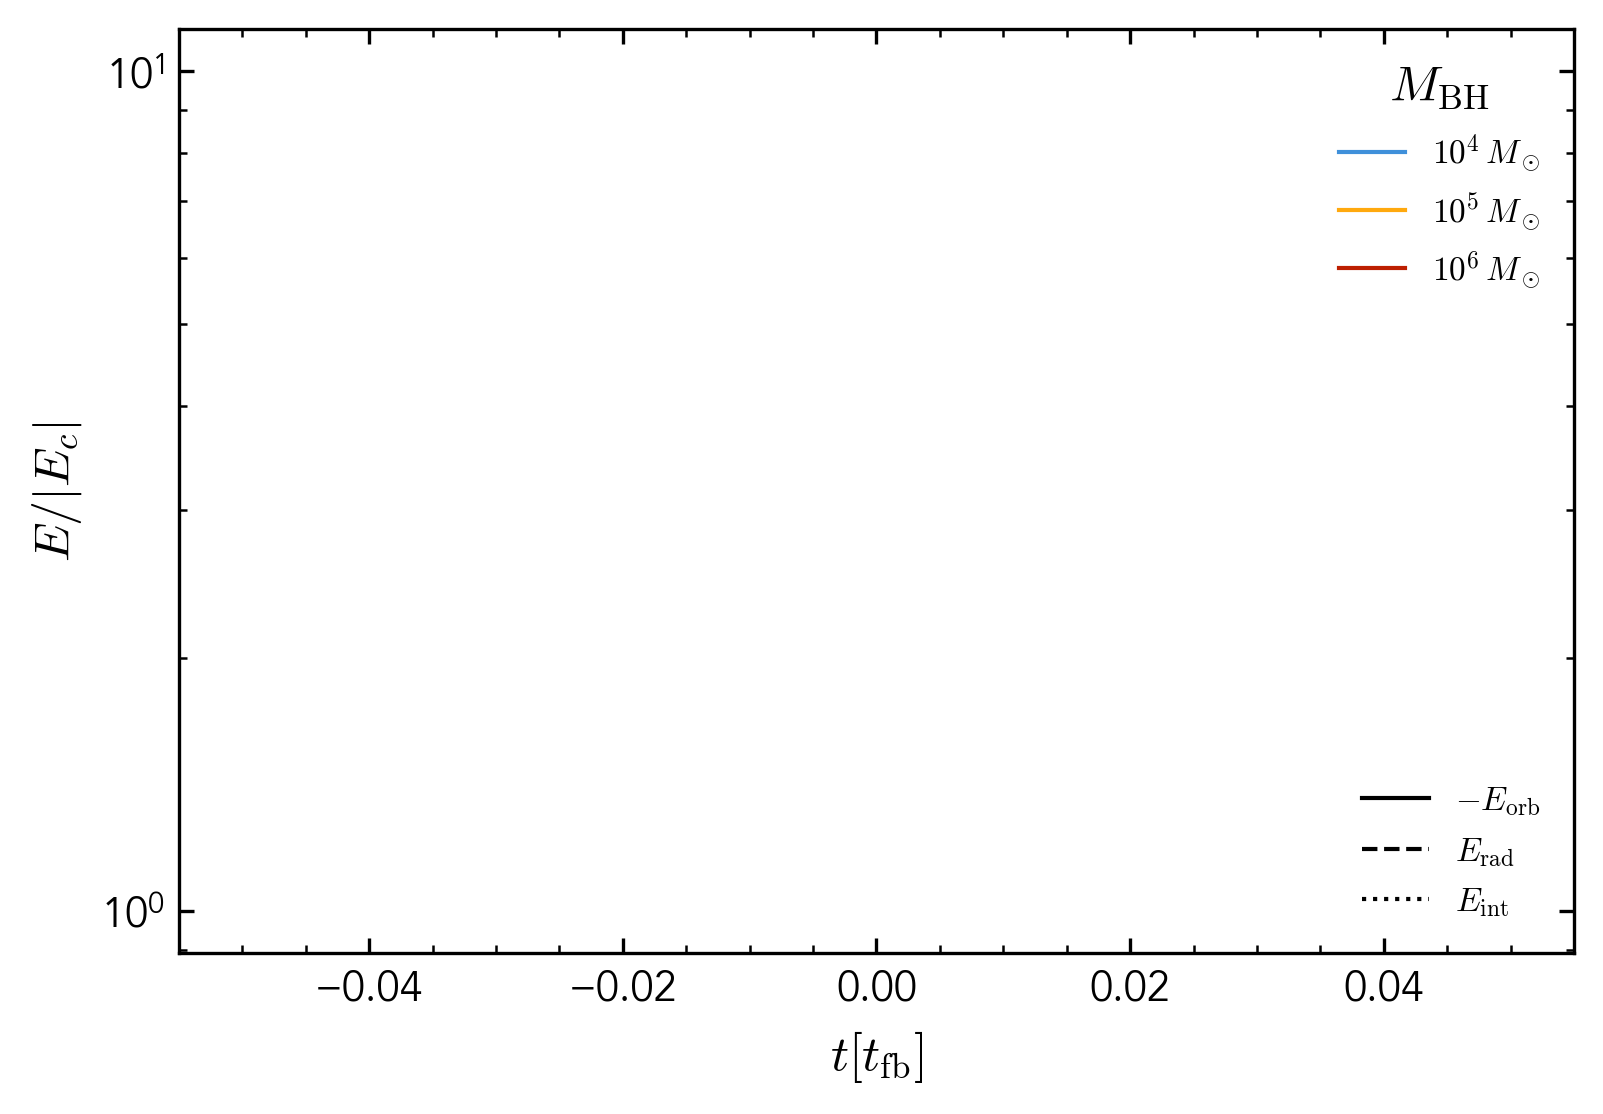

In [11]:
energy_styles = ["-", "--", ":"]
energy_labels = [r"$-E_\mathrm{orb}$", r"$E_\mathrm{rad}$", r"$E_\mathrm{int}$"]

plt.figure(figsize=(6, 4), dpi=300)
for mode, cfg in configs.items():
    datafile = os.path.join(DATADIR, f"E-t-{mode}.txt")
    raw = np.loadtxt(datafile, delimiter="\t").T
    raw = raw[:, np.argsort(raw[1])]
    raw = raw[:, raw[2] >= 0.1]
    t_in_tmins = raw[2]
    Eorb, Erad, Eint = u.unyt_array(
        raw[3:6], "code_length**2*code_mass/code_time**2", registry=reg
    )
    energy_budget = (-Eorb, Erad, Eint)

    for energy, style in zip(energy_budget, energy_styles):
        energy_in_Deltas = energy / cfg["Delta"]
        # Non-positive values cannot be shown on the logarithmic axis.
        positive_energy = np.where(energy_in_Deltas > 0, energy_in_Deltas, np.nan)
        plt.plot(
            t_in_tmins,
            positive_energy,
            color=mode_colors[mode],
            linestyle=style,
            linewidth=1.5,
        )

plt.xlabel(r"$t[t_\mathrm{fb}]$")
plt.ylabel(r"$E/|E_c|$")
plt.yscale("log")

energy_handles = [
    Line2D([], [], color="k", linestyle=s, label=l)
    for s, l in zip(energy_styles, energy_labels)
]
mode_handles = [
    Line2D([], [], color=mode_colors[m], label=mode_labels[m]) for m in configs
]
energy_legend = plt.legend(handles=energy_handles, loc="lower right", fontsize=8)
plt.gca().add_artist(energy_legend)
plt.legend(
    handles=mode_handles, title=r"$M_\mathrm{BH}$", loc="upper right", fontsize=8
)
plt.show()
